# Baseline Rule-Based HVAC Simulation
Simple first-order building model + thermostat controller

In [7]:
import sys
sys.path.append("../src")

import matplotlib.pyplot as plt
import seaborn as sns
from simulate import run_baseline_simulation

# Run 7-day simulation
df = run_baseline_simulation(n_steps=168)

print(f"Total HVAC energy: {df['energy_kWh'].sum():.1f} kWh")
print(f"Average indoor T:  {df['T_in'].mean():.2f} °C")
df.head()

Total HVAC energy: 213.5 kWh
Average indoor T:  19.72 °C


,hour,T_out,Q_solar,Q_internal,Q_HVAC,T_in,energy_J,energy_kWh
0,0,2.745071,0.0,387.730594,0.0,21.000000,0.0,0.0
1,1,2.065197,0.0,362.313192,3000.0,17.336101,10800000.0,3.0
2,2,4.043330,0.0,355.524279,3000.0,16.458452,10800000.0,3.0
3,3,6.627691,0.0,359.209486,3000.0,16.192763,10800000.0,3.0
4,4,5.648770,0.0,396.144915,3000.0,16.545338,10800000.0,3.0


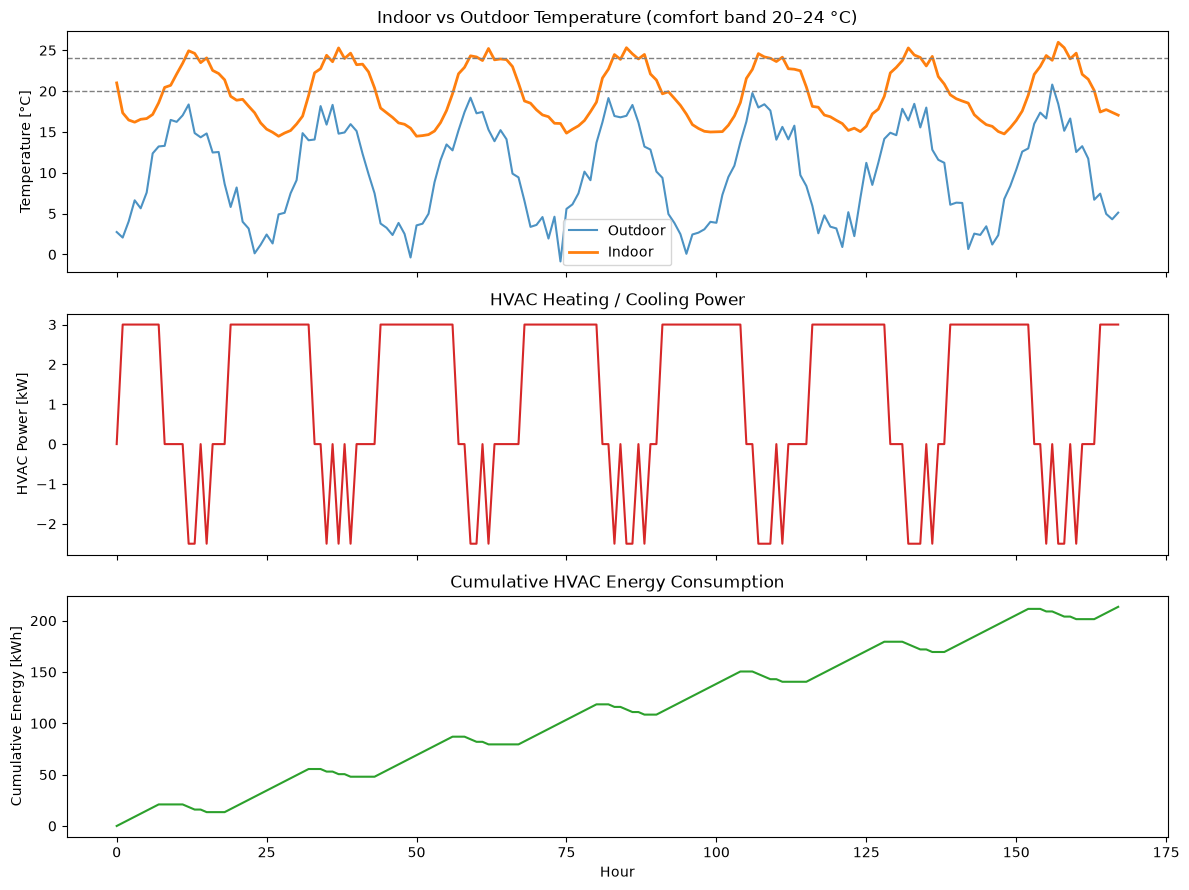

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

# Outdoor vs Indoor temperature
axes[0].plot(df["hour"], df["T_out"], label="Outdoor", color="tab:blue", alpha=0.8)
axes[0].plot(df["hour"], df["T_in"], label="Indoor", color="tab:orange", linewidth=2)
axes[0].axhline(20, color="gray", linestyle="--", linewidth=1)
axes[0].axhline(24, color="gray", linestyle="--", linewidth=1)
axes[0].set_ylabel("Temperature [°C]")
axes[0].legend()
axes[0].set_title("Indoor vs Outdoor Temperature (comfort band 20–24 °C)")

# HVAC power
axes[1].plot(df["hour"], df["Q_HVAC"] / 1000, color="tab:red")
axes[1].set_ylabel("HVAC Power [kW]")
axes[1].set_title("HVAC Heating / Cooling Power")

# Cumulative energy
axes[2].plot(df["hour"], df["energy_kWh"].cumsum(), color="tab:green")
axes[2].set_ylabel("Cumulative Energy [kWh]")
axes[2].set_xlabel("Hour")
axes[2].set_title("Cumulative HVAC Energy Consumption")

plt.tight_layout()
plt.show()